# Skin Cancer Detection (Transfer Learning, EfficientNetB3)

**Dataset:** HAM10000 — 10015 dermatoscopic images, 7 lesion classes.

### Key features
1. **EfficientNet input scaling**: images are passed through `efficientnet.preprocess_input` (which expects raw 0-255 pixels), **not** rescaled to [0,1]. Feeding [0,1] pixels to EfficientNet silently destroys the pretrained features and collapses training to majority-class-only — the single most important fix here.
2. **Augmentation actually runs**: `build_model` now returns `Model(inputs=inputs, ...)` rooted at the real input, so the augmentation layer is inside the graph (the old version returned `Model(inputs=base.input)`, dropping it).
3. **Resolution**: prefer `load_from_folder` with the original JPEGs for true 224x224. The 28x28 CSV path is a fallback — upscaling 28px to 224px is mostly interpolation noise.
4. **Class imbalance**: handled via per-sample weights folded into the `tf.data.Dataset` as `(image, label, sample_weight)`, not `class_weight=` in `model.fit()`.
5. **Weight capping** at 5x to avoid destabilizing the loss on extremely rare classes.
6. **Label sanity check** after loading: asserts the majority class is `nv` (index 4, ~67%) so a label-encoding mismatch fails loudly instead of silently mislabeling every metric.
7. **EarlyStopping + ReduceLROnPlateau**, per-class `classification_report`




## Step 1: Imports & Reproducibility

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU available: []


## Step 2: Config

In [2]:
IMG_SIZE    = 224   # EfficientNetB3 native input size (was 28x28 originally -- major quality loss)
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = 7
LR_INIT     = 1e-4
MAX_CLASS_WEIGHT = 5.0   # cap to avoid destabilizing the loss on extremely rare classes

CLASS_NAMES = {
    0: "akiec - Actinic Keratoses / Intraepithelial Carcinoma",
    1: "bcc   - Basal Cell Carcinoma",
    2: "bkl   - Benign Keratosis-like Lesions",
    3: "df    - Dermatofibroma",
    4: "nv    - Melanocytic Nevi",
    5: "vasc  - Vascular Lesions",
    6: "mel   - Melanoma",
}

## Step 3: Load Data

Loads the HAM10000 28x28 CSV via `kagglehub` (cached after first download). Returns **raw, unresized**
28x28 arrays — resizing to 224x224 happens lazily later, per batch, inside the `tf.data` pipeline
(Step 4), not here. This keeps memory flat regardless of dataset size.

If you instead have the original full-resolution JPEGs + `HAM10000_metadata.csv`, use
`load_from_folder()` instead (returns file paths, also resized lazily later).


In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", dataset_path)


def load_from_csv(path=None):
    """Loads the 28x28 CSV. NOTE: keeps pixels in raw [0,255] float -- do NOT
    rescale to [0,1]. EfficientNet's own preprocess_input expects 0-255 input
    and normalizes internally. Rescaling here was what collapsed training."""
    if path is None:
        path = f"{dataset_path}/hmnist_28_28_RGB.csv"
    df = pd.read_csv(path, dtype=np.uint8)
    X = df.drop(columns=["label"]).values.astype(np.float32)   # keep 0-255
    y = df["label"].values.astype(np.int32)
    X = X.reshape(-1, 28, 28, 3)
    return X, y


def load_from_folder(image_dir="HAM10000_images", metadata_csv="HAM10000_metadata.csv"):
    """Returns file paths + labels (not decoded images) -- decoding/resizing is lazy too.
    This is the path that actually gives real 224x224 resolution. Prefer it over
    load_from_csv when you have the original JPEGs."""
    meta = pd.read_csv(metadata_csv)
    label_map = {"akiec": 0, "bcc": 1, "bkl": 2, "df": 3, "nv": 4, "vasc": 5, "mel": 6}
    paths, labels = [], []
    for _, row in meta.iterrows():
        fpath = os.path.join(image_dir, row["image_id"] + ".jpg")
        if not os.path.exists(fpath):
            continue
        paths.append(fpath)
        labels.append(label_map[row["dx"]])
    return np.array(paths), np.array(labels)

Dataset path: C:\Users\yash_\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2


In [ ]:

print("Loading data ...")
X, y = load_from_csv()
IS_FILEPATHS = False  

# X, y = load_from_folder("HAM10000_images", "HAM10000_metadata.csv")
# IS_FILEPATHS = True

print(f"Dataset shape: {X.shape}, labels: {y.shape}")
counts = dict(zip(*np.unique(y, return_counts=True)))
print(f"Class distribution: {counts}")


majority = max(counts, key=counts.get)
print(f"Majority class index: {majority} ({counts[majority]/len(y):.1%}) -- expected 4 (nv)")
assert majority == 4, "Label mapping mismatch: majority class is not nv(4). Check encoding."

Loading data ...
Dataset shape: (10015, 28, 28, 3), labels: (10015,)
Class distribution: {np.int32(0): np.int64(327), np.int32(1): np.int64(514), np.int32(2): np.int64(1099), np.int32(3): np.int64(115), np.int32(4): np.int64(6705), np.int32(5): np.int64(142), np.int32(6): np.int64(1113)}
Majority class index: 4 (66.9%) -- expected 4 (nv)


## Step 4: Stratified Split + `tf.data` Pipeline (with sample weights)

Defines the resize helpers and `make_dataset()`. **Does not build the datasets yet** — that
happens in Step 5, right after `class_weights` is computed, since `make_dataset()` needs the
weights as an input. This ordering matters: running this cell alone does **not** give you
`train_ds`/`val_ds`/`test_ds`.

> 🔧 Why per-sample weights instead of `class_weight=` in `model.fit()`: when `model.fit()` is given
> a `tf.data.Dataset`, `class_weight=` is unreliable and can silently produce a `ValueError`
> (`cannot use class_weight and sample_weight at the same time`) or, worse, corrupt gradients
> without erroring at all. The fix is to fold the weight **into the dataset itself** as a third
> tensor — `(image, label, sample_weight)` — which Keras handles correctly for any input type.


In [5]:
def make_splits(X, y):
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=SEED)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=0.15, stratify=y_tv, random_state=SEED)
    return X_train, X_val, X_test, y_train, y_val, y_test


def _resize_pixel_array(img, label, weight):
    """img is a raw 0-255 pixel array (e.g. 28x28x3). Resize, then hand off to
    EfficientNet's preprocess_input (expects 0-255, normalizes internally)."""
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)
    return img, label, weight


def _load_and_resize_path(path, label, weight):
    """path is a file path string -- decode the JPEG (0-255), resize, preprocess."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)            # keep 0-255
    img = preprocess_input(img)
    return img, label, weight


def make_dataset(X, y, class_weights=None, batch_size=BATCH_SIZE,
                  training=False, is_filepaths=False):
    """
    Builds a tf.data.Dataset that resizes + preprocesses images lazily, batch by
    batch. class_weights (dict: {class_idx: weight}) is converted to a per-sample
    weight array and folded into the dataset as a third element.
    """
    if class_weights is not None:
        sample_weights = np.array([class_weights[label] for label in y], dtype=np.float32)
    else:
        sample_weights = np.ones(len(y), dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((X, y, sample_weights))
    map_fn = _load_and_resize_path if is_filepaths else _resize_pixel_array
    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

## Step 5: Class Weights (capped) + Build Datasets

**Why class weights at all:** `RandomOverSampler` (used in many tutorials) duplicates exact pixel
copies of minority-class images, which encourages memorizing duplicates rather than learning
generalizable features. Class weights scale the loss contribution per class instead — same
imbalance correction, no duplicated data.

**Why capped at `MAX_CLASS_WEIGHT`:** raw balanced weights for this dataset reach **~12.5x** for the
rarest class (`df`) and **~10x** for `vasc`. Multipliers that large can themselves destabilize
training (large loss spikes, erratic gradients) independent of any other bug. Capping at 5x keeps
the rebalancing benefit without the instability risk.

This cell builds `train_ds` / `val_ds` / `test_ds` immediately after computing weights, since
`make_dataset()` needs `class_weights` as an input. **Only `train_ds` is weighted** — `val_ds` and
`test_ds` stay unweighted so reported metrics reflect true, real-world performance.


In [6]:
def get_class_weights(y_train):
    weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    return dict(enumerate(weights))


if "y_train" not in globals():
    X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X, y)
    print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

class_weights = get_class_weights(y_train)
print("Raw class weights:", class_weights)

class_weights = {k: min(v, MAX_CLASS_WEIGHT) for k, v in class_weights.items()}
print("Capped class weights:", class_weights)

train_ds = make_dataset(X_train, y_train, class_weights=class_weights,
                         training=True, is_filepaths=IS_FILEPATHS)
val_ds = make_dataset(X_val, y_val, class_weights=None,
                       training=False, is_filepaths=IS_FILEPATHS)
test_ds = make_dataset(X_test, y_test, class_weights=None,
                        training=False, is_filepaths=IS_FILEPATHS)


for batch in train_ds.take(1):
    print("Number of elements per batch:", len(batch))
    print("Shapes:", [b.shape for b in batch])

Train: 7235  Val: 1277  Test: 1503
Raw class weights: {0: np.float64(4.37953995157385), 1: np.float64(2.778417818740399), 2: np.float64(1.3017272400143938), 3: np.float64(12.452667814113598), 4: np.float64(0.21337147575793322), 5: np.float64(10.133053221288515), 6: np.float64(1.2855366027007817)}
Capped class weights: {0: np.float64(4.37953995157385), 1: np.float64(2.778417818740399), 2: np.float64(1.3017272400143938), 3: 5.0, 4: np.float64(0.21337147575793322), 5: 5.0, 6: np.float64(1.2855366027007817)}
Number of elements per batch: 3
Shapes: [TensorShape([32, 224, 224, 3]), TensorShape([32]), TensorShape([32])]


## Step 6: Quick EDA — class balance & sample images

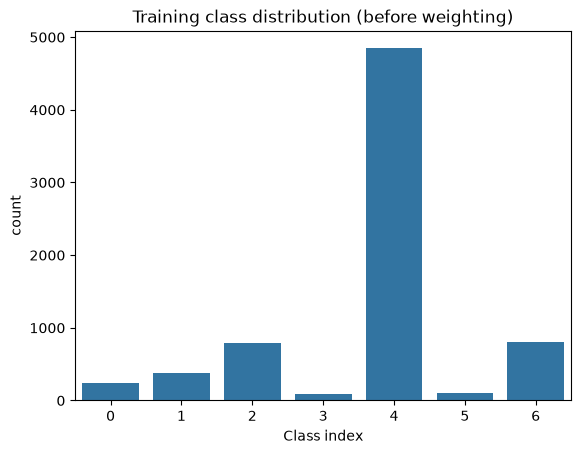

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [20.0..248.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [21.0..239.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.0..177.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [43.0..234.0].


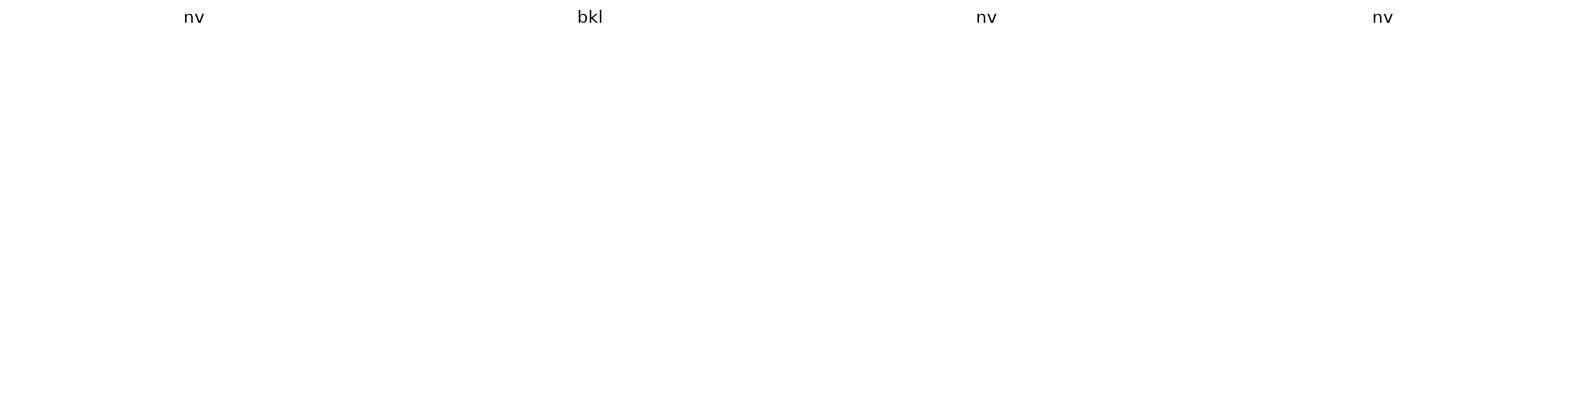

In [7]:
sns.countplot(x=y_train)
plt.title("Training class distribution (before weighting)")
plt.xlabel("Class index")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax in axes:
    idx = random.randint(0, len(X_train) - 1)
    ax.imshow(X_train[idx])
    ax.set_title(CLASS_NAMES[int(y_train[idx])].split('-')[0].strip())
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 7: Data Augmentation

Baked into the model graph as a Keras layer — automatically active only during `model.fit()`
and disabled during `predict()`/`evaluate()`.


In [8]:
def build_augmentation_layer():
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.15),
    ], name="augmentation")

## Step 8: Model — EfficientNetB3 Transfer Learning

EfficientNetB3 pretrained on ImageNet, used as a feature extractor with a custom classification
head on top.


In [9]:
def build_model(num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input")
    x = build_augmentation_layer()(inputs)


    base = EfficientNetB3(include_top=False, weights="imagenet", input_tensor=x)
    base.trainable = False  # frozen for Phase 1

    x = layers.GlobalAveragePooling2D(name="gap")(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base


model, base = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 11,185,974 (42.67 MB)

 Trainable params: 398,855 (1.52 MB)

 Non-trainable params: 10,787,119 (41.15 MB)

## Step 9: Callbacks

- **`ModelCheckpoint`** — saves the best weights per phase.
- **`EarlyStopping`** — stops once validation loss stalls, prevents wasted epochs / overfitting.
- **`ReduceLROnPlateau`** — lowers the learning rate automatically when progress stalls.


In [10]:
def make_callbacks(phase=1):
    ckpt = ModelCheckpoint(
        filepath=f"best_model_phase{phase}.keras",
        monitor="val_accuracy", mode="max", save_best_only=True, verbose=1,
    )
    early = EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1,
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1,
    )
    return [ckpt, early, reduce_lr]

## Step 10: Two-Phase Training

**Phase 1** — backbone frozen, only the new head learns.
**Phase 2** — unfreeze the top 30 backbone layers and fine-tune end-to-end at a 10x lower learning rate.

`train_ds` already yields `(image, label, sample_weight)` triples (Step 5), so `model.fit()` picks
up the per-sample weight automatically from the dataset. **No `class_weight=` argument is passed
here** — combining it with a dataset that already supplies `sample_weight` raises
`ValueError: You cannot class_weight and sample_weight at the same time`, and was also the root
cause of an earlier training collapse where the model only ever predicted the majority class.


In [11]:
def train(train_ds, val_ds):
    model, base = build_model()

    # Phase 1: train head only (backbone frozen)
    model.compile(optimizer=tf.keras.optimizers.Adam(LR_INIT),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print("\n=== Phase 1: Training head (base frozen) ===")
    model.fit(train_ds, validation_data=val_ds,
              epochs=10,
              callbacks=make_callbacks(phase=1))

    # Phase 2: unfreeze top 30 backbone layers (skip BatchNorm to keep stats stable)
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(LR_INIT / 10),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print("\n=== Phase 2: Fine-tuning top backbone layers ===")
    history = model.fit(train_ds, validation_data=val_ds,
                         epochs=EPOCHS,
                         callbacks=make_callbacks(phase=2))
    return model, history


model, history = train(train_ds, val_ds)


=== Phase 1: Training head (base frozen) ===
Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.1900 - loss: 2.1067
Epoch 1: val_accuracy improved from None to 0.44323, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 125s 511ms/step - accuracy: 0.2253 - loss: 1.9536 - val_accuracy: 0.4432 - val_loss: 1.5525 - learning_rate: 1.0000e-04
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.2921 - loss: 1.7274
Epoch 2: val_accuracy improved from 0.44323 to 0.46672, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 110s 487ms/step - accuracy: 0.3001 - loss: 1.6912 - val_accuracy: 0.4667 - val_loss: 1.5460 - learning_rate: 1.0000e-04
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.3514 - loss: 1.5686
Epoch 3: val_accuracy improved from 0.46672 to 0.49961, saving model to best_model_ph

## Step 11: Training Curves

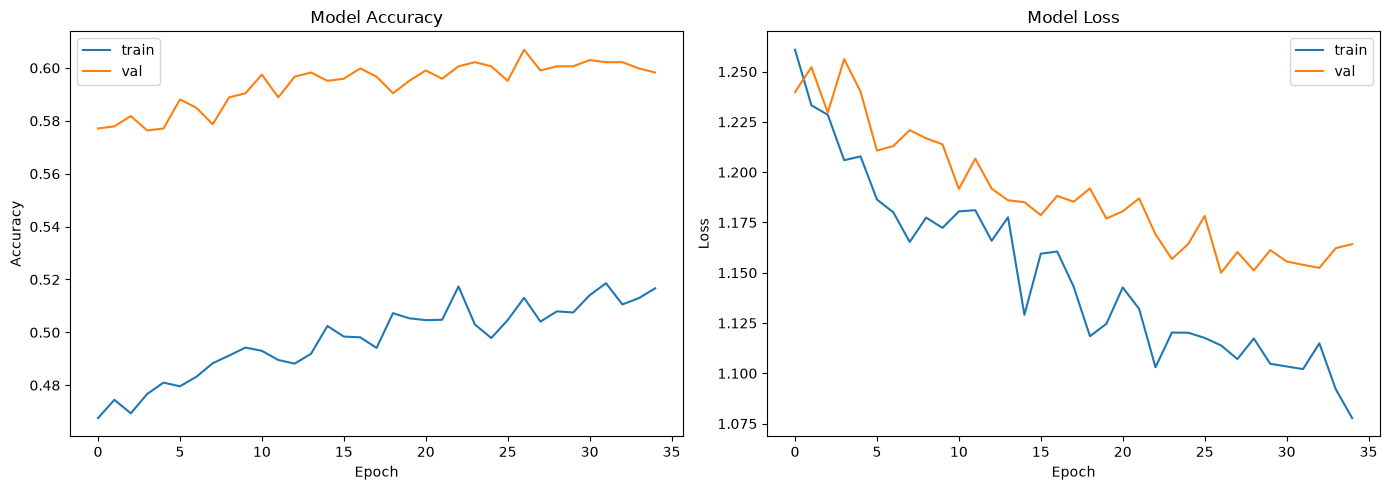

In [12]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(history.history[metric], label="train")
        ax.plot(history.history[f"val_{metric}"], label="val")
        ax.set_title(f"Model {metric.capitalize()}")
        ax.set_xlabel("Epoch"); ax.set_ylabel(metric.capitalize())
        ax.legend()
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()


plot_history(history)

## Step 12: Evaluation — Confusion Matrix + Full Classification Report




Test accuracy: 0.5642
Test loss:     1.2414

47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 427ms/step


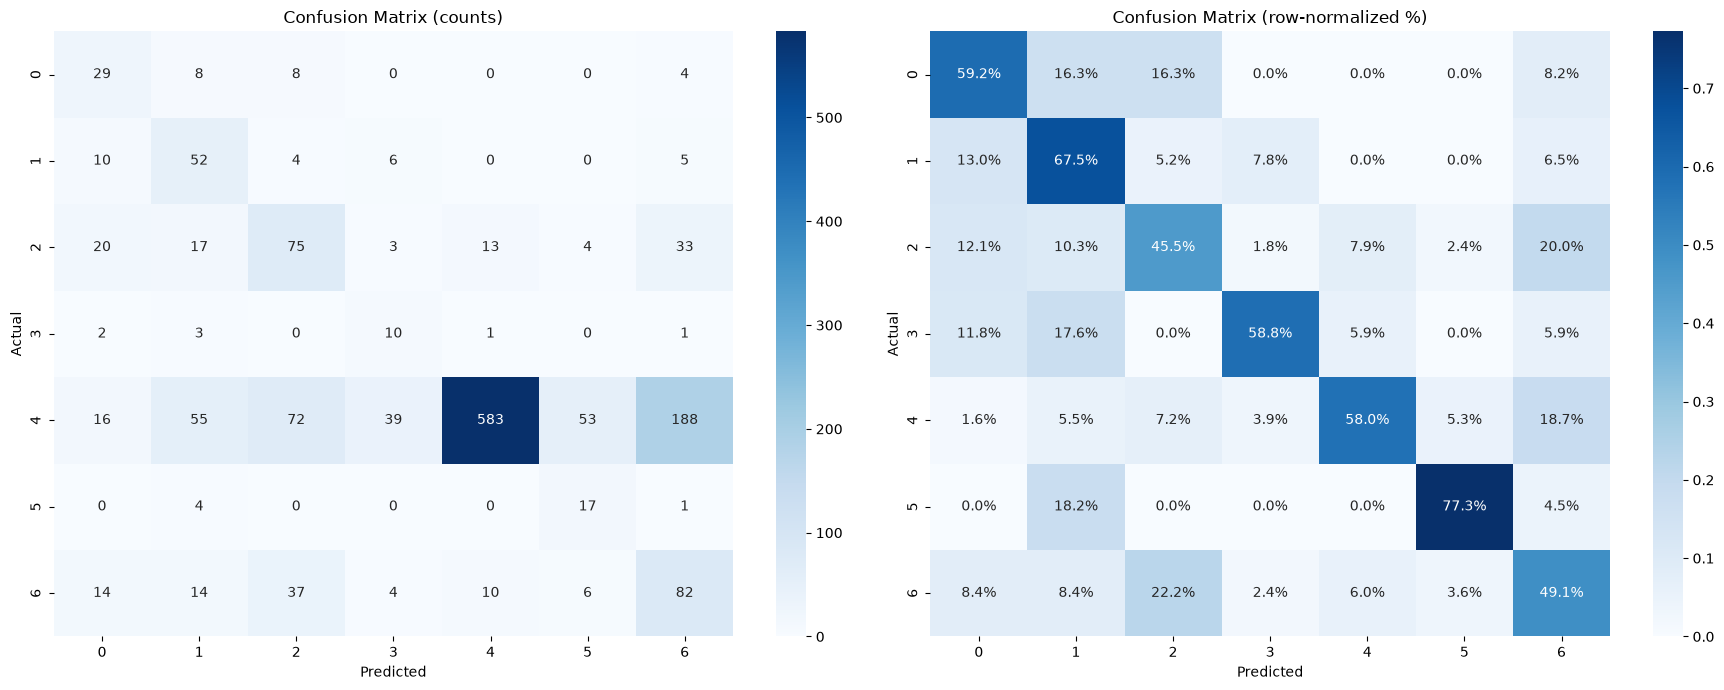

              precision    recall  f1-score   support

       akiec     0.3187    0.5918    0.4143        49
         bcc     0.3399    0.6753    0.4522        77
         bkl     0.3827    0.4545    0.4155       165
          df     0.1613    0.5882    0.2532        17
          nv     0.9605    0.5795    0.7229      1006
        vasc     0.2125    0.7727    0.3333        22
         mel     0.2611    0.4910    0.3410       167

    accuracy                         0.5642      1503
   macro avg     0.3767    0.5933    0.4189      1503
weighted avg     0.7466    0.5642    0.6118      1503



In [13]:
def evaluate(model, test_ds, y_test):
    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"Test accuracy: {acc:.4f}")
    print(f"Test loss:     {loss:.4f}\n")

    y_pred = np.argmax(model.predict(test_ds), axis=1)

    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES), ax=axes[0])
    axes[0].set_title("Confusion Matrix (counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

    sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".1%", cmap="Blues",
                xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES), ax=axes[1])
    axes[1].set_title("Confusion Matrix (row-normalized %)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()

    short_names = [v.split("-")[0].strip() for v in CLASS_NAMES.values()]
    print(classification_report(y_test, y_pred, target_names=short_names, digits=4))


evaluate(model, test_ds, y_test)

## Step 13: Grad-CAM — Explainability

Shows which pixels of the input image most influenced the prediction, by backpropagating
gradients into the last convolutional feature map.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


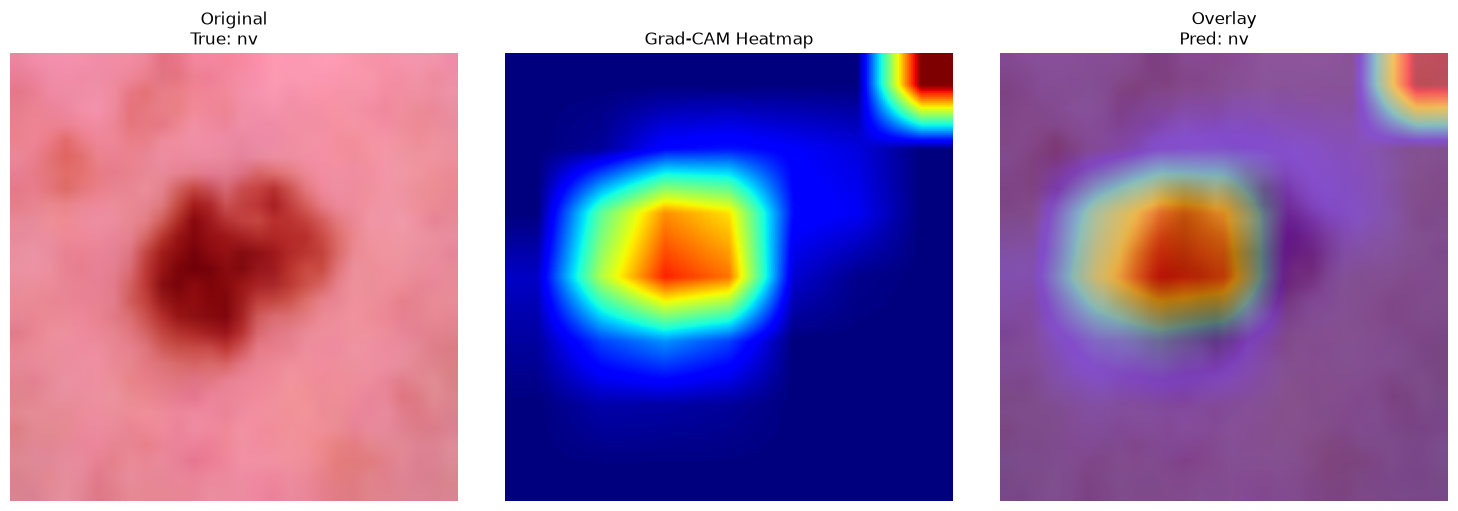

In [14]:
def _last_conv_layer_name(model):
    """Last layer in the full model emitting a 4D feature map -- EfficientNet's
    top_conv. Found by output rank, robust to layer-class naming."""
    name = None
    for l in model.layers:
        try:
            if len(l.output.shape) == 4:
                name = l.name
        except Exception:
            continue
    if name is None:
        raise ValueError("No 4D feature-map layer found.")
    return name


def grad_cam(model, img_array, class_idx=None):
    conv_name = _last_conv_layer_name(model)
    grad_model = Model(model.inputs,
                       [model.get_layer(conv_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(tf.multiply(pooled, conv_out[0]), axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return cam.numpy()


def show_grad_cam(model, img, true_label, pred_label):
    cam = grad_cam(model, img[np.newaxis])
    cam_resized = tf.image.resize(cam[..., np.newaxis], [IMG_SIZE, IMG_SIZE])[..., 0].numpy()

    disp = img - img.min()
    disp = disp / (disp.max() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(disp); axes[0].set_title(f"Original\nTrue: {CLASS_NAMES[true_label].split('-')[0]}")
    axes[1].imshow(cam_resized, cmap="jet"); axes[1].set_title("Grad-CAM Heatmap")
    axes[2].imshow(disp); axes[2].imshow(cam_resized, cmap="jet", alpha=0.45)
    axes[2].set_title(f"Overlay\nPred: {CLASS_NAMES[pred_label].split('-')[0]}")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.savefig("grad_cam.png", dpi=150)
    plt.show()


sample_idx = 0
sample_img, true_lbl, _ = (_load_and_resize_path(X_test[sample_idx], y_test[sample_idx], 1.0)
                            if IS_FILEPATHS else
                            _resize_pixel_array(X_test[sample_idx], y_test[sample_idx], 1.0))
sample_img = sample_img.numpy()
true_lbl = int(true_lbl)
pred_lbl = int(np.argmax(model.predict(sample_img[np.newaxis])))
show_grad_cam(model, sample_img, true_lbl, pred_lbl)

## Step 14: Single-Image Inference (e.g. on a new uploaded photo)

In [15]:
def predict_single(model, image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)          # keep 0-255
    img = preprocess_input(img)             # EfficientNet normalization
    inp = img.numpy()[np.newaxis]

    probs = model.predict(inp)[0]
    pred_idx = int(np.argmax(probs))
    confidence = probs[pred_idx] * 100

    print(f"Predicted : {CLASS_NAMES[pred_idx]}")
    print(f"Confidence: {confidence:.1f}%\n")
    print("All class probabilities:")
    for i, p in enumerate(probs):
        bar = "#" * int(p * 40)
        print(f"  {CLASS_NAMES[i][:42]:42s} {p*100:5.1f}%  {bar}")

    show_grad_cam(model, img.numpy(), pred_idx, pred_idx)
    return pred_idx, confidence

# Example usage:
# predict_single(model, "ISIC_0024306.jpg")

## Step 15: Save Final Model

In [16]:
model.save("skin_cancer_efficientnet_final.keras")
print("Model saved to skin_cancer_efficientnet_final.keras")

Model saved to skin_cancer_efficientnet_final.keras
